In [ ]:
# Core imports are defined in the main implementation cell below.

In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

text = "BPE tokenizers are useful for Transformers."

In [12]:
import struct
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

torch.manual_seed(7)
np.random.seed(7)

DATA_DIR = Path("/Users/arjo/Work/apoai/clip/data/MNIST/raw")
TRAIN_IMAGES = DATA_DIR / "train-images-idx3-ubyte"
TRAIN_LABELS = DATA_DIR / "train-labels-idx1-ubyte"
TEST_IMAGES = DATA_DIR / "t10k-images-idx3-ubyte"
TEST_LABELS = DATA_DIR / "t10k-labels-idx1-ubyte"

DIGIT_NAMES = [
    "zero",
    "one",
    "two",
    "three",
    "four",
    "five",
    "six",
    "seven",
    "eight",
    "nine",
]
DIGIT_PROMPTS = [f"a photo of the digit {name}" for name in DIGIT_NAMES]
MAX_TEXT_LEN = 16

def read_idx_images(path):
    with open(path, "rb") as handle:
        magic, count, rows, cols = struct.unpack(">IIII", handle.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number {magic} in {path}")
        data = np.frombuffer(handle.read(), dtype=np.uint8).copy()
    expected_size = count * rows * cols
    if data.size != expected_size:
        raise ValueError(f"Unexpected image payload size in {path}")
    return data.reshape(count, rows, cols)

def read_idx_labels(path):
    with open(path, "rb") as handle:
        magic, count = struct.unpack(">II", handle.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number {magic} in {path}")
        data = np.frombuffer(handle.read(), dtype=np.uint8).copy()
    if data.size != count:
        raise ValueError(f"Unexpected label payload size in {path}")
    return data

def encode_prompts(prompts):
    encoded = tokenizer(
        prompts,
        padding="max_length",
        truncation=True,
        max_length=MAX_TEXT_LEN,
        return_tensors="pt",
    )
    return encoded["input_ids"], encoded["attention_mask"]

class MNISTCLIPDataset(Dataset):
    def __init__(self, images, labels, input_ids, attention_mask, indices):
        self.images = images[indices]
        self.labels = labels[indices]
        self.input_ids = input_ids
        self.attention_mask = attention_mask

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = torch.from_numpy(self.images[index]).float().unsqueeze(0) / 255.0
        label = int(self.labels[index])
        return (
            image,
            self.input_ids[label],
            self.attention_mask[label],
            torch.tensor(label, dtype=torch.long),
        )

class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, max_len=MAX_TEXT_LEN):
        super(TextEncoder, self).__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed = nn.Embedding(max_len, embed_dim)
        self.projection = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, input_ids, attention_mask):
        positions = torch.arange(input_ids.size(1), device=input_ids.device).unsqueeze(0)
        x = self.token_embed(input_ids) + self.pos_embed(positions)
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        return self.projection(pooled)

class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=128):
        super(ImageEncoder, self).__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, embed_dim),
        )

    def forward(self, x):
        return self.projection(self.backbone(x))

class CLIP(nn.Module):
    def __init__(self, vocab_size, embed_dim=128):
        super(CLIP, self).__init__()
        self.text_encoder = TextEncoder(vocab_size=vocab_size, embed_dim=embed_dim)
        self.image_encoder = ImageEncoder(embed_dim=embed_dim)
        self.logit_scale = nn.Parameter(torch.tensor(np.log(1 / 0.07), dtype=torch.float32))

    def encode_image(self, images):
        return F.normalize(self.image_encoder(images), dim=-1)

    def encode_text(self, input_ids, attention_mask):
        return F.normalize(self.text_encoder(input_ids, attention_mask), dim=-1)

    def forward(self, images, input_ids, attention_mask):
        image_features = self.encode_image(images)
        text_features = self.encode_text(input_ids, attention_mask)
        logit_scale = self.logit_scale.exp().clamp(max=100.0)
        logits_per_image = logit_scale * image_features @ text_features.t()
        logits_per_text = logits_per_image.t()
        targets = torch.arange(images.size(0), device=images.device)
        loss = 0.5 * (
            F.cross_entropy(logits_per_image, targets)
            + F.cross_entropy(logits_per_text, targets)
        )
        return loss, logits_per_image, image_features, text_features

train_images = read_idx_images(TRAIN_IMAGES)
train_labels = read_idx_labels(TRAIN_LABELS)
test_images = read_idx_images(TEST_IMAGES)
test_labels = read_idx_labels(TEST_LABELS)

text_input_ids, text_attention_mask = encode_prompts(DIGIT_PROMPTS)
train_pool_indices = np.random.default_rng(7).permutation(len(train_labels))
train_indices = train_pool_indices[:4000]
val_indices = train_pool_indices[4000:4500]
test_indices = np.random.default_rng(8).permutation(len(test_labels))[:1000]

train_dataset = MNISTCLIPDataset(
    train_images,
    train_labels,
    text_input_ids,
    text_attention_mask,
    train_indices,
)
val_dataset = MNISTCLIPDataset(
    train_images,
    train_labels,
    text_input_ids,
    text_attention_mask,
    val_indices,
)
test_dataset = MNISTCLIPDataset(
    test_images,
    test_labels,
    text_input_ids,
    text_attention_mask,
    test_indices,
)


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model = CLIP(vocab_size=len(tokenizer)).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
}

In [16]:
epochs = 4

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, input_ids, attention_mask, labels in train_loader:
        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        optimizer.zero_grad(set_to_none=True)
        loss, _, _, _ = model(images, input_ids, attention_mask)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        class_text_features = model.encode_text(
            text_input_ids.to(device),
            text_attention_mask.to(device),
        )
        for images, input_ids, attention_mask, labels in val_loader:
            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            val_loss, _, _, _ = model(images, input_ids, attention_mask)
            val_running_loss += val_loss.item() * images.size(0)

            scores = model.encode_image(images) @ class_text_features.t()
            predictions = scores.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_epoch_loss = val_running_loss / len(val_loader.dataset)
    val_epoch_accuracy = val_correct / val_total

    history["train_loss"].append(epoch_loss)
    history["val_loss"].append(val_epoch_loss)
    history["val_accuracy"].append(val_epoch_accuracy)
    print(
        f"epoch {epoch + 1}/{epochs} - train loss: {epoch_loss:.4f} "
        f"val loss: {val_epoch_loss:.4f} val acc: {val_epoch_accuracy:.3f}"
    )


epoch 1/4 - train loss: 2.8817 val loss: 2.9002 val acc: 0.930
epoch 2/4 - train loss: 2.8462 val loss: 2.8709 val acc: 0.934
epoch 3/4 - train loss: 2.8408 val loss: 2.8793 val acc: 0.942
epoch 4/4 - train loss: 2.8437 val loss: 2.8519 val acc: 0.946


test top-1 digit retrieval accuracy: 0.956


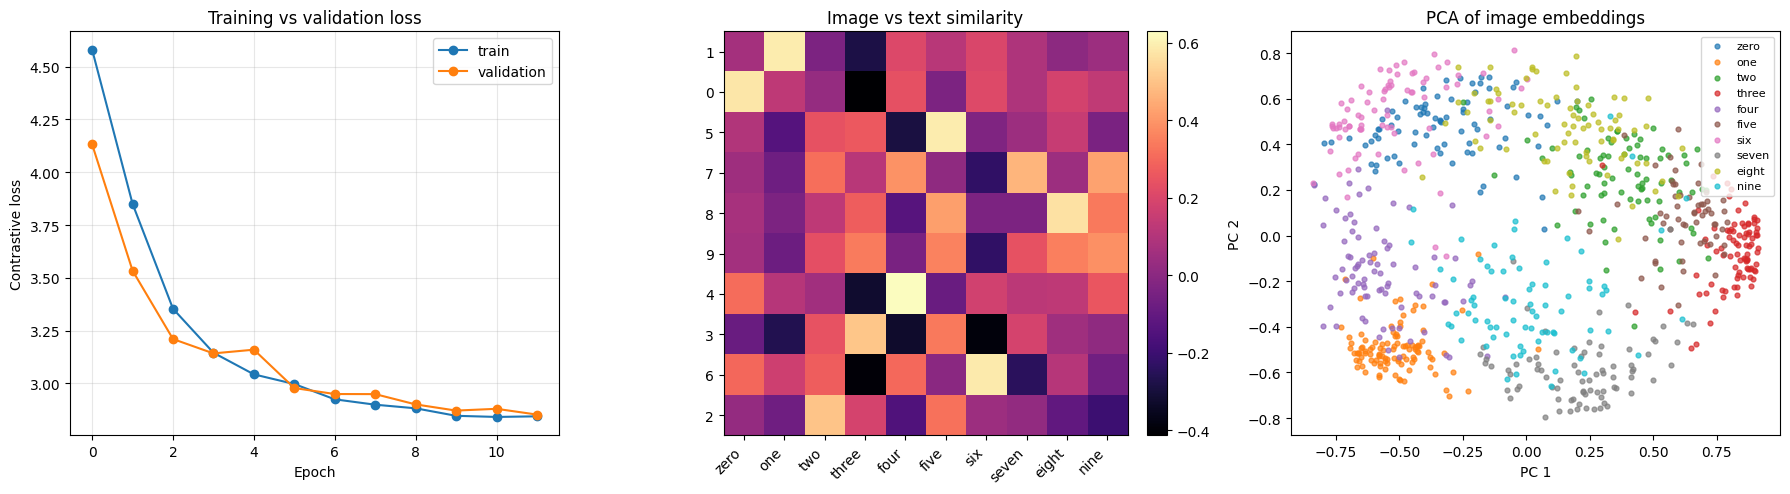

In [18]:
model.eval()
with torch.no_grad():
    class_text_features = model.encode_text(
        text_input_ids.to(device),
        text_attention_mask.to(device),
    )

    seen_labels = set()
    example_images = []
    example_labels = []
    for index in range(len(test_dataset)):
        image, _, _, label = test_dataset[index]
        label_value = int(label)
        if label_value not in seen_labels:
            seen_labels.add(label_value)
            example_images.append(image)
            example_labels.append(label_value)
        if len(example_images) == 10:
            break

    example_images = torch.stack(example_images).to(device)
    example_image_features = model.encode_image(example_images)
    similarity = example_image_features @ class_text_features.t()

    test_correct = 0
    test_total = 0
    for images, _, _, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        scores = model.encode_image(images) @ class_text_features.t()
        predictions = scores.argmax(dim=1)
        test_correct += (predictions == labels).sum().item()
        test_total += labels.size(0)

    test_accuracy = test_correct / test_total
    print(f"test top-1 digit retrieval accuracy: {test_accuracy:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history["train_loss"], marker="o", label="train")
axes[0].plot(history["val_loss"], marker="o", label="validation")
axes[0].set_title("Training vs validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Contrastive loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

heatmap = axes[1].imshow(similarity.cpu().numpy(), cmap="magma")
axes[1].set_title("Image vs text similarity")
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(DIGIT_NAMES, rotation=45, ha="right")
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(example_labels)
fig.colorbar(heatmap, ax=axes[1], fraction=0.046, pad=0.04)

probe_count = min(800, len(test_dataset))
probe_images = []
probe_labels = []
for index in range(probe_count):
    image, _, _, label = test_dataset[index]
    probe_images.append(image)
    probe_labels.append(int(label))

probe_images = torch.stack(probe_images).to(device)
probe_features = model.encode_image(probe_images)
centered = probe_features - probe_features.mean(dim=0, keepdim=True)
_, _, v = torch.linalg.svd(centered, full_matrices=False)
projection = centered @ v[:2].t()
projection = projection.cpu().detach().numpy()
probe_labels = np.array(probe_labels)

for label_value, color in enumerate(plt.cm.tab10(np.linspace(0, 1, 10))):
    mask = probe_labels == label_value
    axes[2].scatter(
        projection[mask, 0],
        projection[mask, 1],
        s=12,
        alpha=0.7,
        color=color,
        label=DIGIT_NAMES[label_value],
    )

axes[2].set_title("PCA of image embeddings")
axes[2].set_xlabel("PC 1")
axes[2].set_ylabel("PC 2")
axes[2].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()
